# Stage 8-1: XGBoost Raw SHAP Interpretation

This supplementary notebook interprets the fixed XGBoost model on the raw multiclass-output scale. The 118 transformed features are grouped to the 69 original predictors before destination-specific rankings are produced.


## Part 1: Fixed inputs


In [1]:
# 1: Import packages

from pathlib import Path
import json
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import xgboost as xgb

from IPython.display import display
from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

print("Python:", sys.version.split()[0])
print("SHAP:", shap.__version__)
print("XGBoost:", xgb.__version__)

Python: 3.12.13
SHAP: 0.52.0
XGBoost: 3.2.0


In [2]:
# 2: Check software versions

version_checks = {
    "Python 3.12 or later": sys.version_info >= (3, 12),
    "SHAP 0.52.0": shap.__version__ == "0.52.0",
    "XGBoost 3.2.0": xgb.__version__ == "3.2.0",
}

version_audit = pd.DataFrame({
    "Check": version_checks.keys(),
    "Passed": version_checks.values(),
})

display(version_audit)

if not version_audit["Passed"].all():
    raise RuntimeError("Use the shap_xgb312 kernel.")


,Check,Passed
0,Python 3.12 or later,True
1,SHAP 0.52.0,True
2,XGBoost 3.2.0,True


In [3]:
# 3: Set project paths

working_directory = Path.cwd().resolve()

project_root = next(
    (
        directory
        for directory in [working_directory, *working_directory.parents]
        if (
            directory
            / "data_derived"
            / "stage_3_final_modelling_dataset"
            / "final_modelling_dataset.csv"
        ).is_file()
        and (
            directory
            / "data_derived"
            / "stage_6_held_out_test_evaluation"
            / "stage_6_frozen_model_specifications.csv"
        ).is_file()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError("Required Stage 3 and Stage 6 inputs could not be located.")

data_derived = project_root / "data_derived"

stage_2_dir = data_derived / "stage_2_predictor_construction"
stage_3_dir = data_derived / "stage_3_final_modelling_dataset"
stage_4_dir = data_derived / "stage_4_modelling_design"
stage_6_dir = data_derived / "stage_6_held_out_test_evaluation"
stage_8_dir = data_derived / "stage_8_shap_interpretation"


In [4]:
# 4: Define required files

paths = {
    "data": stage_3_dir / "final_modelling_dataset.csv",
    "split": stage_4_dir / "stage_4_train_test_split.csv",
    "roles": stage_4_dir / "stage_4_predictor_preprocessing_roles.csv",
    "search": stage_4_dir / "stage_4_model_search_specification.csv",
    "model specifications": stage_6_dir / "stage_6_frozen_model_specifications.csv",
    "test predictions": stage_6_dir / "stage_6_test_predictions.csv",
    "predictor manifest": stage_2_dir / "stage_2_final_predictor_manifest.csv",
    "background": stage_8_dir / "stage_8_shap_background.csv",
    "RF feature map": stage_8_dir / "stage_8_rf_feature_mapping.csv",
}

missing = [name for name, path in paths.items() if not path.is_file()]

if missing:
    raise FileNotFoundError("Missing input file(s): " + ", ".join(missing))


In [5]:
# 5: Load the fixed records

data = pd.read_csv(paths["data"], dtype={"NSID": "string"})
split = pd.read_csv(paths["split"], dtype={"NSID": "string"})
roles = pd.read_csv(paths["roles"])
search_spec = pd.read_csv(paths["search"])
model_spec = pd.read_csv(paths["model specifications"])
stage_6_predictions = pd.read_csv(
    paths["test predictions"],
    dtype={"NSID": "string"},
)
predictor_manifest = pd.read_csv(paths["predictor manifest"])
background_register = pd.read_csv(
    paths["background"],
    dtype={"NSID": "string"},
)
rf_feature_map = pd.read_csv(paths["RF feature map"])


In [6]:
# 6: Prepare the training and test samples

# Apply the fixed Stage 4 participant split.
train_ids = set(split.loc[split["sample"].eq("Training"), "NSID"])
test_ids = set(split.loc[split["sample"].eq("Test"), "NSID"])

train = data.loc[data["NSID"].isin(train_ids)].copy().reset_index(drop=True)
test = data.loc[data["NSID"].isin(test_ids)].copy().reset_index(drop=True)

predictors = roles["Predictor"].tolist()
numeric = roles.loc[
    roles["Preprocessing role"].eq("Numeric"),
    "Predictor",
].tolist()
categorical = roles.loc[
    roles["Preprocessing role"].eq("Categorical"),
    "Predictor",
].tolist()

for predictor in numeric:
    train[predictor] = pd.to_numeric(train[predictor], errors="raise")
    test[predictor] = pd.to_numeric(test[predictor], errors="raise")

print("Training participants:", len(train))
print("Test participants:", len(test))
print("Predictors:", len(predictors))

Training participants: 7619
Test participants: 1905
Predictors: 69


In [7]:
# 7: Set outcome labels and colours

# Use one class number, label and colour for each destination.
outcome_labels = {
    0: "Education",
    1: "Employment",
    2: "Apprenticeship or training",
    3: "Unemployment or inactivity (NEET)",
}

outcome_colours = {
    "Education": "tab:blue",
    "Employment": "tab:orange",
    "Apprenticeship or training": "tab:green",
    "Unemployment or inactivity (NEET)": "tab:red",
}

code_to_class = {1: 0, 4: 1, 5: 2, 6: 3}

train["y"] = train["age18_outcome_code"].map(code_to_class).astype(int)
test["y"] = test["age18_outcome_code"].map(code_to_class).astype(int)

In [8]:
# 8: Check analysis alignment

alignment_checks = {
    "7,619 training participants": len(train) == 7_619,
    "1,905 held-out test participants": len(test) == 1_905,
    "69 original predictors": len(predictors) == 69,
    "500 background participants": len(background_register) == 500,
    "Background IDs are training IDs": set(background_register["NSID"]).issubset(train_ids),
    "Feature map contains 69 original predictors": rf_feature_map["Original predictor"].nunique() == 69,
}

alignment_audit = pd.DataFrame({
    "Check": alignment_checks.keys(),
    "Passed": alignment_checks.values(),
})

display(alignment_audit)

if not alignment_audit["Passed"].all():
    raise AssertionError("Stage 8-1 inputs are not aligned.")


,Check,Passed
0,"7,619 training participants",True
1,"1,905 held-out test participants",True
2,69 original predictors,True
3,500 background participants,True
4,Background IDs are training IDs,True
5,Feature map contains 69 original predictors,True


## Part 2: Fixed XGBoost model


In [9]:
# 1: Build the tree-model preprocessor

# Impute numeric features and one-hot encode categorical features.
tree_preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ]), numeric),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            drop="if_binary",
        )),
    ]), categorical),
])

tree_preprocessor.fit(train[predictors])

xgb_feature_names = tree_preprocessor.get_feature_names_out().tolist()

print("Transformed XGBoost features:", len(xgb_feature_names))

Transformed XGBoost features: 118


In [10]:
# 2: Prepare background and test inputs

# Transform the 500 training-background participants and all test cases.
background_ids = background_register["NSID"].tolist()

background_data = (
    train.set_index("NSID")
    .loc[background_ids, predictors]
    .reset_index(drop=True)
)

def dense_array(values):
    if sparse.issparse(values):
        return values.toarray()
    return np.asarray(values)

xgb_background = dense_array(
    tree_preprocessor.transform(background_data)
)
xgb_test = dense_array(
    tree_preprocessor.transform(test[predictors])
)

print("Background shape:", xgb_background.shape)
print("Test shape:", xgb_test.shape)

Background shape: (500, 118)
Test shape: (1905, 118)


In [11]:
# 3: Check transformed-feature alignment

# Confirm that XGBoost uses the registered 118 transformed features in order.
rf_feature_names = (
    rf_feature_map
    .sort_values("Position")["Transformed feature"]
    .tolist()
)

feature_alignment = pd.DataFrame([{
    "Registered transformed features": len(rf_feature_names),
    "XGBoost transformed features": len(xgb_feature_names),
    "Names and order match": rf_feature_names == xgb_feature_names,
}])

display(feature_alignment)

if not feature_alignment["Names and order match"].all():
    raise AssertionError("Transformed feature names or order do not match.")

,Registered transformed features,XGBoost transformed features,Names and order match
0,118,118,True


In [12]:
# 4: Read the fixed XGBoost specification

# Read the frozen model settings and random state.
xgb_row = model_spec.loc[model_spec["Model"].eq("XGBoost")].iloc[0]
xgb_parameters = json.loads(xgb_row["Selected parameters"])
xgb_weighting = xgb_row["Selected weighting mode"]

search_index = search_spec.set_index("Model")
rf_fixed = json.loads(
    search_index.loc["Random forest", "Fixed parameters"]
)
model_random_state = int(rf_fixed["random_state"])

print("Weighting mode:", xgb_weighting)
print("Model random state:", model_random_state)

Weighting mode: Balanced
Model random state: 424242


In [13]:
# 5: Fit the fixed XGBoost model

xgb_estimator = XGBClassifier(
    **xgb_parameters,
    objective="multi:softprob",
    num_class=4,
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=model_random_state,
    verbosity=0,
)

xgb_train = dense_array(
    tree_preprocessor.transform(train[predictors])
)

if xgb_weighting == "Balanced":
    weights = compute_sample_weight(
        "balanced",
        train["y"],
    )
    xgb_estimator.fit(
        xgb_train,
        train["y"],
        sample_weight=weights,
    )
else:
    xgb_estimator.fit(xgb_train, train["y"])


In [14]:
# 6: Check held-out outputs

probability_columns = [
    "Probability Education",
    "Probability Employment",
    "Probability Apprenticeship or training",
    "Probability Unemployment or inactivity (NEET)",
]

stored_xgb = (
    stage_6_predictions.loc[
        stage_6_predictions["Model"].eq("XGBoost")
    ]
    .set_index("NSID")
    .reindex(test["NSID"])
)

xgb_predictions = xgb_estimator.predict(xgb_test).astype(int)
xgb_probabilities = xgb_estimator.predict_proba(xgb_test)
stored_probabilities = stored_xgb[probability_columns].to_numpy()

xgb_reproduction = pd.DataFrame([{
    "Model": "XGBoost",
    "Predictions match": np.array_equal(
        xgb_predictions,
        stored_xgb["Predicted internal class"].to_numpy(dtype=int),
    ),
    "Probabilities match": np.allclose(
        xgb_probabilities,
        stored_probabilities,
        atol=1e-10,
        rtol=1e-8,
    ),
    "Matching cases": int(np.sum(
        xgb_predictions
        == stored_xgb["Predicted internal class"].to_numpy(dtype=int)
    )),
    "Test cases": len(test),
    "Max probability difference": float(
        np.max(np.abs(xgb_probabilities - stored_probabilities))
    ),
}])

display(xgb_reproduction)

if not xgb_reproduction[
    ["Predictions match", "Probabilities match"]
].all().all():
    raise AssertionError("XGBoost does not reproduce the Stage 6 held-out outputs.")


,Model,Predictions match,Probabilities match,Matching cases,Test cases,Max probability difference
0,XGBoost,True,True,1905,1905,1.110223e-16


In [15]:
# 7: Save the model reproduction check

xgb_reproduction.to_csv(
    stage_8_dir / "stage_8_xgboost_model_reproduction.csv",
    index=False,
)


## Part 3: XGBoost raw TreeSHAP

TreeSHAP explains the four raw XGBoost outputs using the fixed training background and all held-out cases.


In [16]:
# 1: Build the XGBoost SHAP explainer

# Explain the model on its raw multiclass output scale.
xgb_masker = shap.maskers.Independent(
    xgb_background,
    max_samples=500,
)

xgb_explainer = shap.TreeExplainer(
    xgb_estimator,
    data=xgb_masker,
    feature_perturbation="interventional",
    model_output="raw",
)

In [17]:
# 2: Run a small technical check

# Check whether SHAP values rebuild the four raw outputs for 10 test cases.
xgb_small = xgb_test[:10]

small_values = xgb_explainer.shap_values(
    xgb_small,
    check_additivity=False,
)

if isinstance(small_values, list):
    small_values = np.stack(
        small_values,
        axis=-1,
    )

small_values = np.asarray(small_values)
expected = np.asarray(xgb_explainer.expected_value)
rebuilt = small_values.sum(axis=1) + expected

small_raw_outputs = xgb_estimator.predict(
    xgb_small,
    output_margin=True,
)

xgb_shap_audit = pd.DataFrame([{
    "Model": "XGBoost",
    "Samples": len(xgb_small),
    "Outputs": small_values.shape[-1],
    "Max raw-output error": np.max(
        np.abs(rebuilt - small_raw_outputs)
    ),
}])

xgb_shap_audit["Passed"] = (
    xgb_shap_audit["Outputs"].eq(4)
    & xgb_shap_audit["Max raw-output error"].lt(1e-4)
)

display(xgb_shap_audit)

if not xgb_shap_audit["Passed"].all():
    raise AssertionError(
        "XGBoost raw TreeSHAP technical check failed."
    )

 95%|=================== | 38/40 [00:17<00:00]       

,Model,Samples,Outputs,Max raw-output error,Passed
0,XGBoost,10,4,0.000002,True


In [18]:
# 3: Calculate full XGBoost raw SHAP values

# Explain all 1,905 held-out cases for the four raw XGBoost outputs.
xgb_shap = xgb_explainer.shap_values(
    xgb_test,
    check_additivity=False,
)

if isinstance(xgb_shap, list):
    xgb_shap = np.stack(
        xgb_shap,
        axis=-1,
    )

xgb_shap = np.asarray(xgb_shap)

print("XGBoost SHAP shape:", xgb_shap.shape)

100%|===================| 7617/7620 [69:25<00:01]        

XGBoost SHAP shape: (1905, 118, 4)


In [19]:
# 4: Check full-sample raw-output additivity

# Check whether SHAP values rebuild the raw outputs for all test cases.
expected = np.asarray(xgb_explainer.expected_value)
rebuilt = xgb_shap.sum(axis=1) + expected

xgb_raw_outputs = xgb_estimator.predict(
    xgb_test,
    output_margin=True,
)

xgb_full_audit = pd.DataFrame([{
    "Model": "XGBoost",
    "Max raw-output error": np.max(
        np.abs(rebuilt - xgb_raw_outputs)
    ),
}])

xgb_full_audit["Passed"] = (
    xgb_full_audit["Max raw-output error"].lt(1e-4)
)

display(xgb_full_audit)

if not xgb_full_audit["Passed"].all():
    raise AssertionError(
        "Full XGBoost raw TreeSHAP additivity check failed."
    )

,Model,Max raw-output error,Passed
0,XGBoost,0.000004,True


In [20]:
# 5: Save the XGBoost raw SHAP array

# Save the full raw-output attribution array and expected values.
np.savez_compressed(
    stage_8_dir / "stage_8_xgboost_raw_shap.npz",
    values=xgb_shap,
    expected_value=np.asarray(xgb_explainer.expected_value),
)

print("Saved XGBoost raw SHAP array.")

Saved XGBoost raw SHAP array.


## Part 4: Original-predictor XGBoost attribution

Encoded SHAP values are summed within each original predictor before absolute grouped values are used for destination-specific ranking.


In [21]:
# 1: Group SHAP values to 69 original predictors

# Add encoded SHAP values that belong to the same original predictor.
grouped_values = []

for predictor in predictors:
    positions = rf_feature_map.loc[
        rf_feature_map["Original predictor"].eq(predictor),
        "Position",
    ].to_numpy()

    grouped_values.append(
        xgb_shap[:, positions, :].sum(axis=1)
    )

xgb_grouped_shap = np.stack(
    grouped_values,
    axis=1,
)

print(
    "Grouped XGBoost SHAP shape:",
    xgb_grouped_shap.shape,
)

Grouped XGBoost SHAP shape: (1905, 69, 4)


In [22]:
# 2: Calculate destination-specific XGBoost attribution

# Rank original predictors by mean absolute raw SHAP within each destination.
importance_tables = []

for class_number, outcome in outcome_labels.items():
    values = np.abs(
        xgb_grouped_shap[:, :, class_number]
    ).mean(axis=0)

    table = pd.DataFrame({
        "Outcome": outcome,
        "Predictor": predictors,
        "Mean absolute raw SHAP": values,
    })

    table["Rank"] = (
        table["Mean absolute raw SHAP"]
        .rank(method="first", ascending=False)
        .astype(int)
    )

    importance_tables.append(table)

xgb_importance = (
    pd.concat(importance_tables, ignore_index=True)
    .sort_values(["Outcome", "Rank"])
    .reset_index(drop=True)
)

xgb_importance.to_csv(
    stage_8_dir / "stage_8_xgboost_raw_shap_by_destination.csv",
    index=False,
)

display(
    xgb_importance.groupby("Outcome").head(6)
)

,Outcome,Predictor,Mean absolute raw SHAP,Rank
0,Apprenticeship or training,parental_higher_education_expectation_pretrans...,0.213574,1
1,Apprenticeship or training,highest_parental_qualification_code,0.194370,2
2,Apprenticeship or training,ethnicity,0.156569,3
3,Apprenticeship or training,academic_self_concept_score,0.153036,4
4,Apprenticeship or training,school_attitude_score,0.123752,5
5,Apprenticeship or training,sex,0.117067,6
69,Education,higher_education_application_likelihood,0.328887,1
70,Education,parental_higher_education_expectation_pretrans...,0.147042,2
71,Education,expected_post16_route,0.107984,3
72,Education,parental_training_apprenticeship_discussion_pr...,0.073545,4


In [23]:
# 3: Save the XGBoost top six by destination

# Keep the six highest-ranked predictors for each destination.
xgb_top6 = (
    xgb_importance.loc[
        xgb_importance["Rank"].le(6)
    ]
    .sort_values(["Outcome", "Rank"])
    .reset_index(drop=True)
)

xgb_top6.to_csv(
    stage_8_dir / "stage_8_xgboost_raw_shap_top6_by_destination.csv",
    index=False,
)

display(xgb_top6)

,Outcome,Predictor,Mean absolute raw SHAP,Rank
0,Apprenticeship or training,parental_higher_education_expectation_pretrans...,0.213574,1
1,Apprenticeship or training,highest_parental_qualification_code,0.194370,2
2,Apprenticeship or training,ethnicity,0.156569,3
3,Apprenticeship or training,academic_self_concept_score,0.153036,4
4,Apprenticeship or training,school_attitude_score,0.123752,5
5,Apprenticeship or training,sex,0.117067,6
6,Education,higher_education_application_likelihood,0.328887,1
7,Education,parental_higher_education_expectation_pretrans...,0.147042,2
8,Education,expected_post16_route,0.107984,3
9,Education,parental_training_apprenticeship_discussion_pr...,0.073545,4


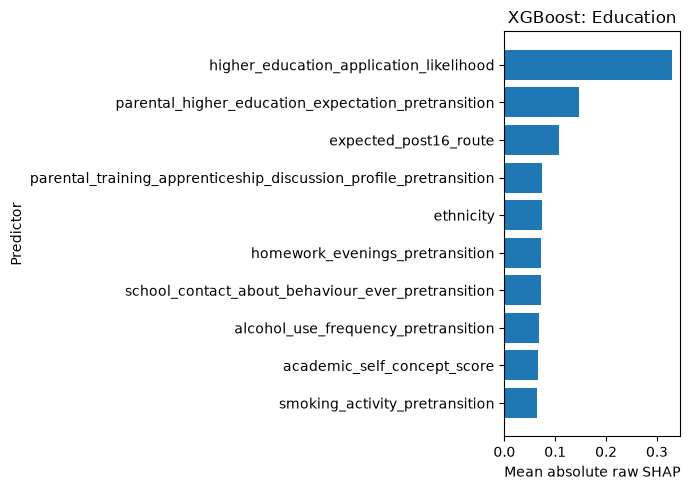

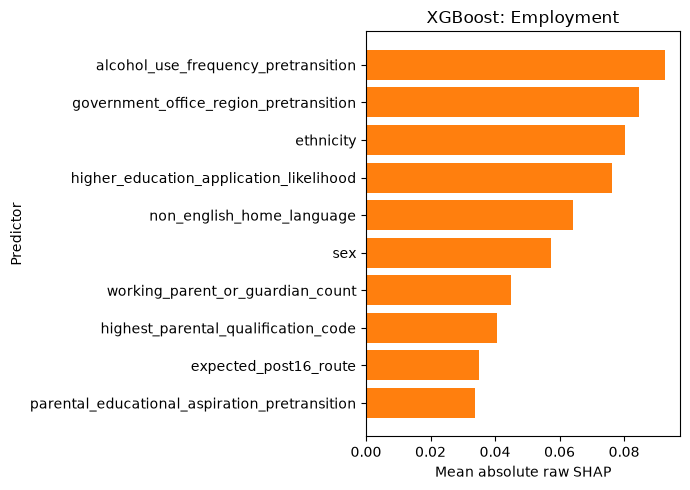

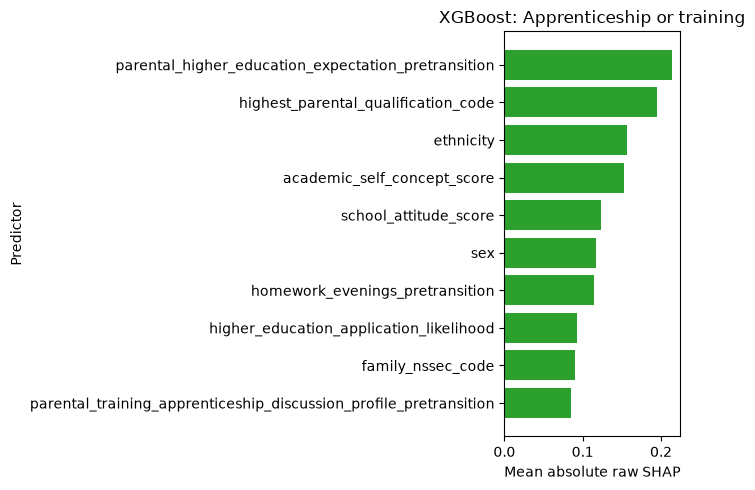

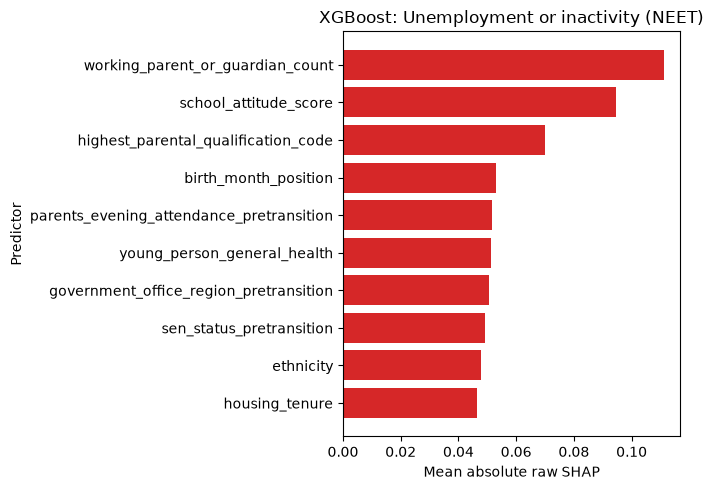

In [24]:
# 4: Plot leading XGBoost predictors

# Plot the ten largest mean absolute raw SHAP values for each destination.
for outcome in outcome_labels.values():
    current = (
        xgb_importance.loc[
            xgb_importance["Outcome"].eq(outcome)
        ]
        .nsmallest(10, "Rank")
        .sort_values("Mean absolute raw SHAP")
    )

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.barh(
        current["Predictor"],
        current["Mean absolute raw SHAP"],
        color=outcome_colours[outcome],
    )

    ax.set_xlabel("Mean absolute raw SHAP")
    ax.set_ylabel("Predictor")
    ax.set_title(f"XGBoost: {outcome}")
    fig.tight_layout()

    slug = re.sub(
        r"[^a-z0-9]+",
        "_",
        outcome.lower(),
    ).strip("_")

    fig.savefig(
        stage_8_dir / f"stage_8_xgboost_raw_shap_{slug}.png",
        dpi=150,
        bbox_inches="tight",
    )

    display(fig)
    plt.close(fig)

## Part 5: Final audit


In [25]:
# 1: Run the final audit

required_outputs = [
    "stage_8_xgboost_model_reproduction.csv",
    "stage_8_xgboost_raw_shap.npz",
    "stage_8_xgboost_raw_shap_by_destination.csv",
    "stage_8_xgboost_raw_shap_top6_by_destination.csv",
]

final_checks = {
    "XGBoost reproduces Stage 6 predictions and probabilities": (
        xgb_reproduction[
            ["Predictions match", "Probabilities match"]
        ].all().all()
    ),
    "XGBoost raw SHAP technical check passed": (
        xgb_shap_audit["Passed"].all()
    ),
    "XGBoost raw additivity check passed": (
        xgb_full_audit["Passed"].all()
    ),
    "XGBoost grouped SHAP has expected shape": (
        xgb_grouped_shap.shape == (1905, 69, 4)
    ),
    "Each destination has six leading predictors": (
        xgb_top6.groupby("Outcome").size().eq(6).all()
        and xgb_top6["Outcome"].nunique() == 4
    ),
    "All required outputs exist": all(
        (stage_8_dir / file_name).is_file()
        for file_name in required_outputs
    ),
}

final_audit = pd.DataFrame({
    "Check": final_checks.keys(),
    "Passed": final_checks.values(),
})

display(final_audit)

if not final_audit["Passed"].all():
    raise AssertionError("Stage 8-1 XGBoost audit failed.")


,Check,Passed
0,XGBoost reproduces Stage 6 predictions and pro...,True
1,XGBoost raw SHAP technical check passed,True
2,XGBoost raw additivity check passed,True
3,XGBoost grouped SHAP has expected shape,True
4,Each destination has six leading predictors,True
5,All required outputs exist,True


In [26]:
# 2: Save the final audit

final_audit.to_csv(
    stage_8_dir / "stage_8_xgboost_raw_shap_final_audit.csv",
    index=False,
)

print("Stage 8-1 audit passed.")


Stage 8-1 audit passed.


## Interpretation

XGBoost TreeSHAP was run separately in the `shap_xgb312` environment. The resulting SHAP values are on the raw XGBoost output scale, so direct comparison with the RF probability-scale SHAP results is not made here.

A separate probability-scale comparison of RF and XGBoost is provided in Stage 8-2.